# Final de la Champions League 2014/15: Barcelona vs Juventus

Análisis exploratorio con datos abiertos de **StatsBomb** (`statsbombpy`) y visualización con `mplsoccer`.

## Contexto

- **Partido:** Juventus 1 – 3 Barcelona
- **Fecha:** 6 de junio de 2015
- **Estadio:** Olympiastadion, Berlín
- **Goles:** Rakitić (4'), Morata (55'), Suárez (68'), Neymar (90+7')

El Barcelona de Luis Enrique, con el tridente Messi–Suárez–Neymar, conquistó su quinta Copa de Europa y cerró el triplete de la temporada.

## Preguntas

1. ¿Qué equipo generó más volumen ofensivo (tiros y goles)?
2. ¿Quién dominó el balón (pases, precisión de pase y posesión)?
3. ¿Desde dónde disparó cada equipo y con qué calidad de ocasión (xG)?

## 1. Carga de datos

Flujo habitual con `statsbombpy`: `competitions` → `matches` → filtrar el partido → `events`.

In [1]:
import warnings
from statsbombpy import sb

# Usamos los datos abiertos, así que ocultamos el aviso de "sin credenciales"
warnings.filterwarnings('ignore', message='credentials were not supplied')

# Cargar todas las competiciones disponibles
competitions = sb.competitions()

# Filtrar por Champions League
champions_league = competitions[competitions['competition_name'] == 'Champions League']
champions_league

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
3,16,4,Europe,Champions League,male,False,False,2018/2019,2026-05-15T15:54:04.598614,2021-06-13T16:17:31.694,NaN,2026-05-15T15:54:04.598614
4,16,1,Europe,Champions League,male,False,False,2017/2018,2024-02-13T02:35:28.134882,2021-06-13T16:17:31.694,NaN,2024-02-13T02:35:28.134882
5,16,2,Europe,Champions League,male,False,False,2016/2017,2024-02-13T02:37:32.205154,2021-06-13T16:17:31.694,NaN,2024-02-13T02:37:32.205154
6,16,27,Europe,Champions League,male,False,False,2015/2016,2024-06-12T07:45:38.786894,2021-06-13T16:17:31.694,NaN,2024-06-12T07:45:38.786894
7,16,26,Europe,Champions League,male,False,False,2014/2015,2024-02-12T12:49:54.914228,2021-06-13T16:17:31.694,NaN,2024-02-12T12:49:54.914228
8,16,25,Europe,Champions League,male,False,False,2013/2014,2024-02-12T12:48:48.479157,2021-06-13T16:17:31.694,NaN,2024-02-12T12:48:48.479157
9,16,24,Europe,Champions League,male,False,False,2012/2013,2024-02-12T12:47:34.340413,2021-06-13T16:17:31.694,NaN,2024-02-12T12:47:34.340413
10,16,23,Europe,Champions League,male,False,False,2011/2012,2024-02-13T02:36:35.698340,2021-06-13T16:17:31.694,NaN,2024-02-13T02:36:35.698340
11,16,22,Europe,Champions League,male,False,False,2010/2011,2024-02-12T12:53:03.944320,2021-06-13T16:17:31.694,NaN,2024-02-12T12:53:03.944320
12,16,21,Europe,Champions League,male,False,False,2009/2010,2024-02-12T12:49:25.017694,2021-06-13T16:17:31.694,NaN,2024-02-12T12:49:25.017694


In [2]:
# competition_id y season_id de la Champions 2014/2015 (ver tabla anterior)
matches = sb.matches(competition_id=16, season_id=26)

# Buscamos el partido de la final (Barcelona vs Juventus)
final = matches[(matches['home_team'] == 'Barcelona') | (matches['away_team'] == 'Barcelona')]
final[['match_date', 'home_team', 'away_team', 'home_score', 'away_score', 'competition_stage']]

,match_date,home_team,away_team,home_score,away_score,competition_stage
0,2015-06-06,Juventus,Barcelona,1,3,Final


In [3]:
# Cogemos el match_id de la final
match_id = final[final['competition_stage'] == 'Final']['match_id'].values[0]
match_id

np.int64(18242)

In [4]:
# Cargar todos los eventos del partido
events = sb.events(match_id=match_id)

# Ver cuántos eventos hay y qué columnas tenemos
print(events.shape)
events.head()

(3433, 80)


,ball_receipt_outcome,ball_recovery_recovery_failure,carry_end_location,clearance_aerial_won,counterpress,dribble_nutmeg,dribble_outcome,dribble_overrun,duel_outcome,duel_type,...,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"{'formation': 41212, 'lineup': [{'player': {'i...",Juventus,224,00:00:00.000,Starting XI,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"{'formation': 41221, 'lineup': [{'player': {'i...",Barcelona,217,00:00:00.000,Starting XI,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Juventus,224,00:00:00.000,Half Start,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Barcelona,217,00:00:00.000,Half Start,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Juventus,224,00:00:00.000,Half Start,NaN


## 2. Métricas básicas del partido

Disparos, goles, xG, pases, precisión de pase y posesión aproximada por equipo.

In [5]:
# 1. DISPAROS
shots = events[events['type'] == 'Shot']
shots_por_equipo = shots.groupby('team').size()
print("Disparos por equipo:")
print(shots_por_equipo)

# Goles (disparos cuyo resultado fue gol)
goals = shots[shots['shot_outcome'] == 'Goal']
goals_por_equipo = goals.groupby('team').size()
print("\nGoles por equipo:")
print(goals_por_equipo)

# xG acumulado (suma del xG de StatsBomb de cada disparo)
xg_por_equipo = shots.groupby('team')['shot_statsbomb_xg'].sum()
print("\nxG por equipo:")
print(xg_por_equipo.round(2))

# 2. PASES
passes = events[events['type'] == 'Pass']
passes_por_equipo = passes.groupby('team').size()
print("\nPases por equipo:")
print(passes_por_equipo)

# Precisión de pase (pases completados vs totales)
# En StatsBomb, un pase fallido tiene algo en 'pass_outcome'; uno completado tiene NaN ahí
passes_completados = passes[passes['pass_outcome'].isna()]
precision = passes_completados.groupby('team').size() / passes_por_equipo * 100
print("\nPrecisión de pase (%):")
print(precision.round(1))

# 3. POSESIÓN (aproximada por nº de eventos con balón por equipo)
posesion = events['possession_team'].value_counts(normalize=True) * 100
print("\nPosesión aproximada por nº de eventos (%):")
print(posesion.round(1))

Disparos por equipo:
team
Barcelona    17
Juventus     15
dtype: int64

Goles por equipo:
team
Barcelona    3
Juventus     1
dtype: int64

xG por equipo:
team
Barcelona    2.27
Juventus     1.38
Name: shot_statsbomb_xg, dtype: float64

Pases por equipo:
team
Barcelona    600
Juventus     377
dtype: int64

Precisión de pase (%):
team
Barcelona    85.8
Juventus     78.2
dtype: float64

Posesión aproximada por nº de eventos (%):
possession_team
Barcelona    60.1
Juventus     39.9
Name: proportion, dtype: float64


> **Nota sobre la posesión:** el porcentaje anterior es **posesión por nº de eventos**, no por tiempo. Se cuenta qué proporción de eventos ocurre mientras cada equipo tiene la posesión (`possession_team`). No equivale al tiempo real con balón que dan las retransmisiones: StatsBomb no ofrece directamente la duración continua de cada posesión, y una secuencia con muchos pases cortos genera más eventos que otra de igual duración con pocos toques. Sirve como aproximación para comparar equipos, no como dato exacto.

## 3. Mapa de xG

Cada punto es un disparo. El **tamaño** es proporcional a su xG (probabilidad de gol según StatsBomb). Los puntos **rellenos** son goles y los **huecos**, disparos fallados. Las coordenadas de la Juventus están volteadas para que cada equipo ataque hacia una portería distinta: Barcelona hacia la derecha y Juventus hacia la izquierda.

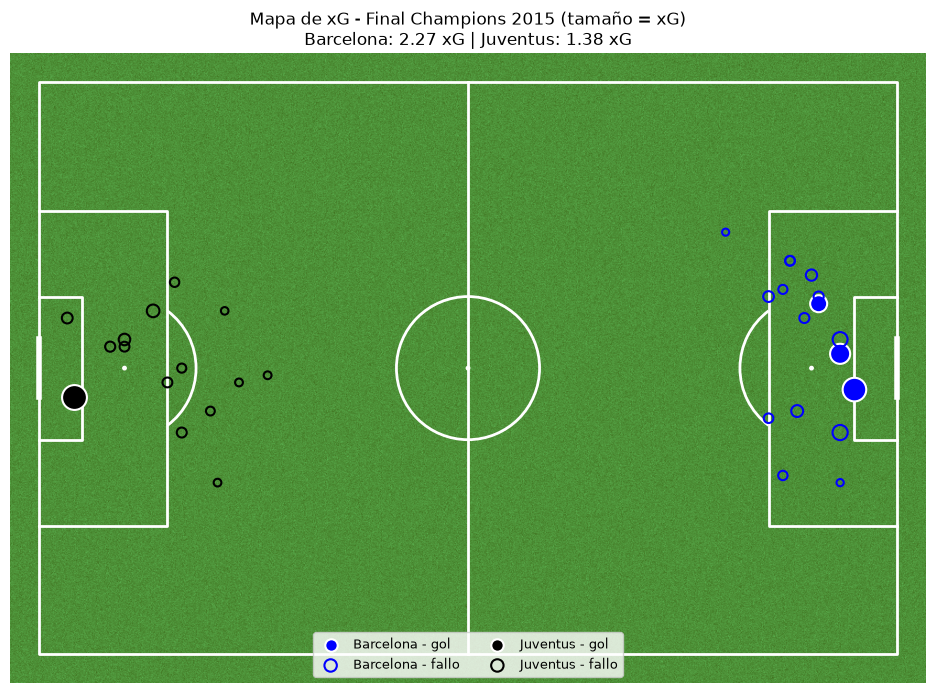

In [6]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

pitch = Pitch(pitch_type='statsbomb', pitch_color='grass', line_color='white')
fig, ax = pitch.draw(figsize=(10, 7))

for team, color in zip(['Barcelona', 'Juventus'], ['blue', 'black']):
    team_shots = shots[shots['team'] == team]
    x = team_shots['location'].apply(lambda loc: loc[0])
    y = team_shots['location'].apply(lambda loc: loc[1])

    # Volteamos las coordenadas de Juventus para que ataque hacia la portería izquierda
    if team == 'Juventus':
        x = 120 - x
        y = 80 - y

    # Tamaño proporcional al xG (con un mínimo para que los tiros de xG muy bajo se vean)
    size = team_shots['shot_statsbomb_xg'] * 500 + 20
    is_goal = team_shots['shot_outcome'] == 'Goal'

    pitch.scatter(x[is_goal], y[is_goal], ax=ax, s=size[is_goal],
                  facecolors=color, edgecolors='white', linewidths=1.5,
                  label=f'{team} - gol')
    pitch.scatter(x[~is_goal], y[~is_goal], ax=ax, s=size[~is_goal],
                  facecolors='none', edgecolors=color, linewidths=1.5,
                  label=f'{team} - fallo')

# Tamaño fijo en la leyenda (si no, cada marcador hereda el tamaño de su primer tiro)
legend = ax.legend(loc='lower center', ncol=2, fontsize=9)
for handle in legend.legend_handles:
    handle.set_sizes([80])

# xG total por equipo (goles + fallos) en el título, no en la leyenda
xg_texto = ' | '.join(f'{team}: {xg:.2f} xG' for team, xg in xg_por_equipo.items())
plt.title(f'Mapa de xG - Final Champions 2015 (tamaño = xG)\n{xg_texto}')
plt.show()

## 4. Conclusiones

- **Volumen y calidad ofensiva:** el Barcelona disparó algo más (17 tiros frente a 15), pero la gran diferencia está en la calidad de las ocasiones. Generó **2,27 xG** frente a **1,38** de la Juventus y marcó 3 goles, ligeramente por encima de lo esperado.
- **Dónde se dispara:** casi todos los tiros del Barcelona (16 de 17) salen del área, lo que indica que llegaba a zonas de remate de alta probabilidad. Aproximadamente la mitad de los disparos de la Juventus son desde fuera del área, con xG muy bajo (puntos pequeños y huecos en el mapa).
- **Ocasiones claras:** la Juventus tuvo la ocasión individual de mayor xG del partido (el gol de Morata, ~0,60 xG), pero no generó suficientes ocasiones de calidad para compensar.
- **Balón:** el Barcelona dio más pases (600 frente a 377) y con mejor precisión (85,8 % frente a 78,2 %). También tuvo más posesión por nº de eventos (60 % frente a 40 %). Encaja con un partido controlado por el equipo de Luis Enrique.

**Limitaciones:** se trata de un único partido, la posesión es una aproximación por eventos (ver nota) y el xG es el modelo propio de StatsBomb.